<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/Solar_Power_Generation_Prediction_and_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('solar_plant_generation_dataset.csv')

In [ ]:
df.head()

,timestamp,solar_irradiance_wm2,ambient_temperature_c,panel_temperature_c,cloud_cover_percent,power_generation_kw
0,2025-01-01 00:00:00,0.0,23.06,23.06,35.37,0.0
1,2025-01-01 01:00:00,0.0,28.04,28.04,20.70,0.0
2,2025-01-01 02:00:00,0.0,24.97,24.97,16.00,0.0
3,2025-01-01 03:00:00,0.0,17.90,17.90,3.14,0.0
4,2025-01-01 04:00:00,0.0,24.27,24.27,25.09,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              5000 non-null   object 
 1   solar_irradiance_wm2   5000 non-null   float64
 2   ambient_temperature_c  5000 non-null   float64
 3   panel_temperature_c    5000 non-null   float64
 4   cloud_cover_percent    5000 non-null   float64
 5   power_generation_kw    5000 non-null   float64
dtypes: float64(5), object(1)
memory usage: 234.5+ KB


In [ ]:
df.describe()

,solar_irradiance_wm2,ambient_temperature_c,panel_temperature_c,cloud_cover_percent,power_generation_kw
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,264.333098,27.241034,30.545242,28.450732,40.040302
std,328.756478,6.041576,8.487863,16.244769,50.950095
min,0.000000,9.120000,9.840000,0.340000,0.000000
25%,0.000000,22.980000,23.800000,15.575000,0.000000
50%,0.000000,26.725000,29.150000,26.565000,0.000000
75%,568.732500,31.192500,36.742500,39.065000,82.925000
max,1159.750000,49.300000,57.860000,90.830000,233.150000


In [ ]:
# Ensure timestamp is in datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time (important for any time-based split later if needed)
df = df.sort_values("timestamp").reset_index(drop=True)

# Time features
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Cyclical encoding for hour (captures daily periodicity)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Optional: cyclical month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df.head()

,timestamp,solar_irradiance_wm2,ambient_temperature_c,panel_temperature_c,cloud_cover_percent,power_generation_kw,hour,day,month,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2025-01-01 00:00:00,0.0,23.06,23.06,35.37,0.0,0,1,1,2,0,0.000000,1.000000,0.5,0.866025
1,2025-01-01 01:00:00,0.0,28.04,28.04,20.70,0.0,1,1,1,2,0,0.258819,0.965926,0.5,0.866025
2,2025-01-01 02:00:00,0.0,24.97,24.97,16.00,0.0,2,1,1,2,0,0.500000,0.866025,0.5,0.866025
3,2025-01-01 03:00:00,0.0,17.90,17.90,3.14,0.0,3,1,1,2,0,0.707107,0.707107,0.5,0.866025
4,2025-01-01 04:00:00,0.0,24.27,24.27,25.09,0.0,4,1,1,2,0,0.866025,0.500000,0.5,0.866025


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   timestamp              5000 non-null   datetime64[ns]
 1   solar_irradiance_wm2   5000 non-null   float64       
 2   ambient_temperature_c  5000 non-null   float64       
 3   panel_temperature_c    5000 non-null   float64       
 4   cloud_cover_percent    5000 non-null   float64       
 5   power_generation_kw    5000 non-null   float64       
 6   hour                   5000 non-null   int32         
 7   day                    5000 non-null   int32         
 8   month                  5000 non-null   int32         
 9   dayofweek              5000 non-null   int32         
 10  is_weekend             5000 non-null   int64         
 11  hour_sin               5000 non-null   float64       
 12  hour_cos               5000 non-null   float64       
 13  mon

In [ ]:
df.isna().sum()

,0
timestamp,0
solar_irradiance_wm2,0
ambient_temperature_c,0
panel_temperature_c,0
cloud_cover_percent,0
power_generation_kw,0
hour,0
day,0
month,0
dayofweek,0


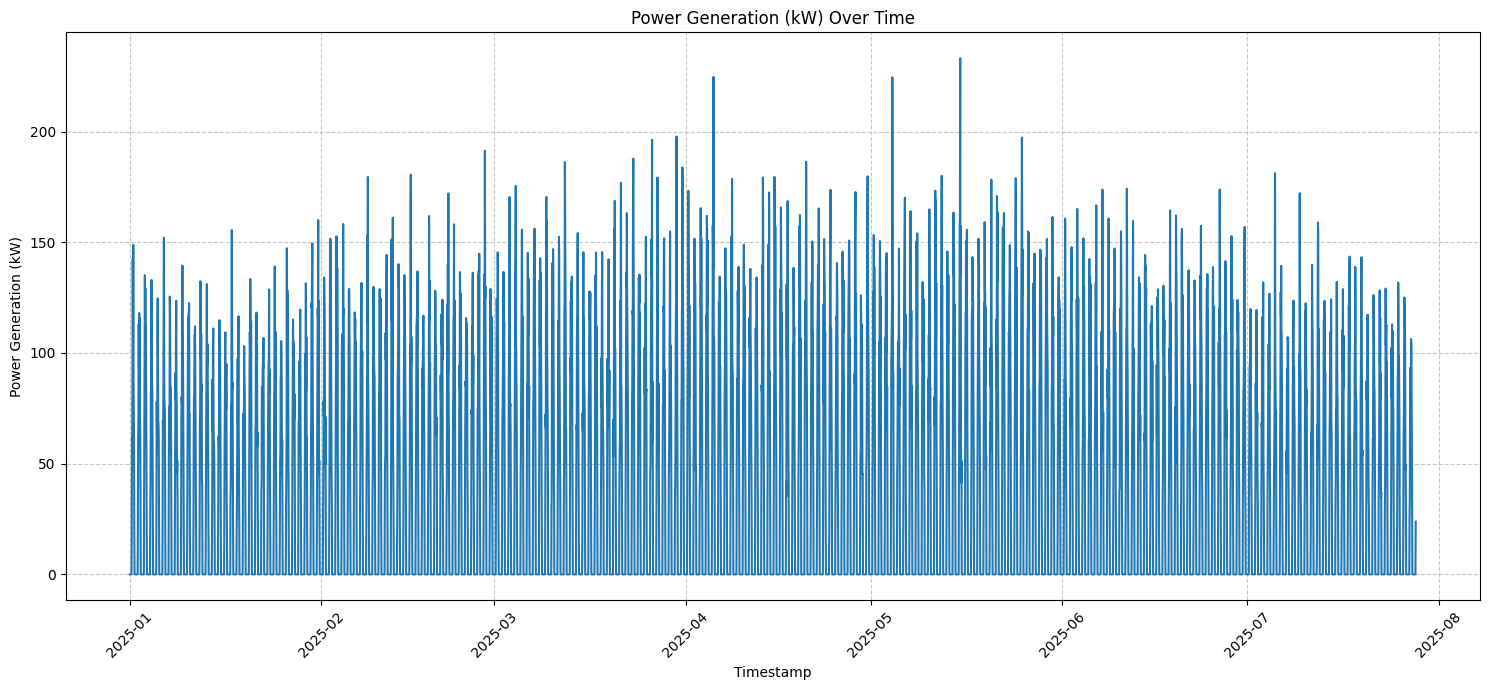

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='power_generation_kw', data=df)
plt.title('Power Generation (kW) Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Power Generation (kW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

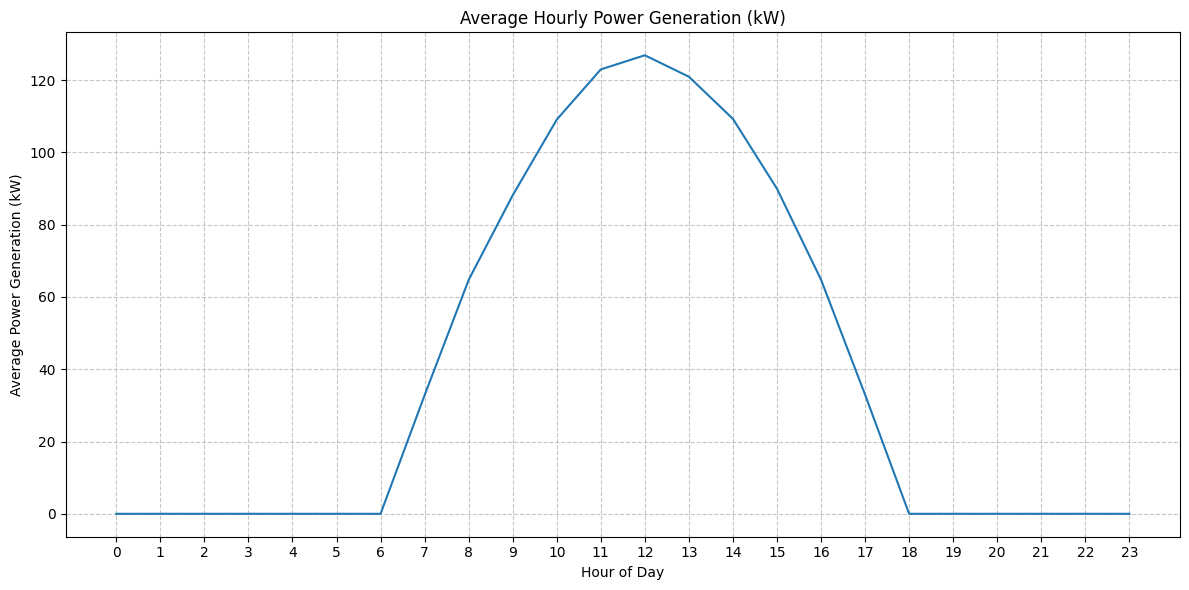

In [ ]:
# Calculate average hourly power generation
avg_hourly_generation = df.groupby('hour')['power_generation_kw'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='power_generation_kw', data=avg_hourly_generation)
plt.title('Average Hourly Power Generation (kW)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Power Generation (kW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

* Maximum average generation occurs at Hour 12 (12:00 PM), reaching approximately 127 kW.
* Nighttime (00:00 – 06:00 & 18:00 – 23:00): Generation is strictly 0 kW. Half of your dataset consists of zero values.

* Daytime (06:00 – 18:00): Power production begins ramping up right at 06:00 (6 AM) and completely drops to zero by 18:00 (6 PM).

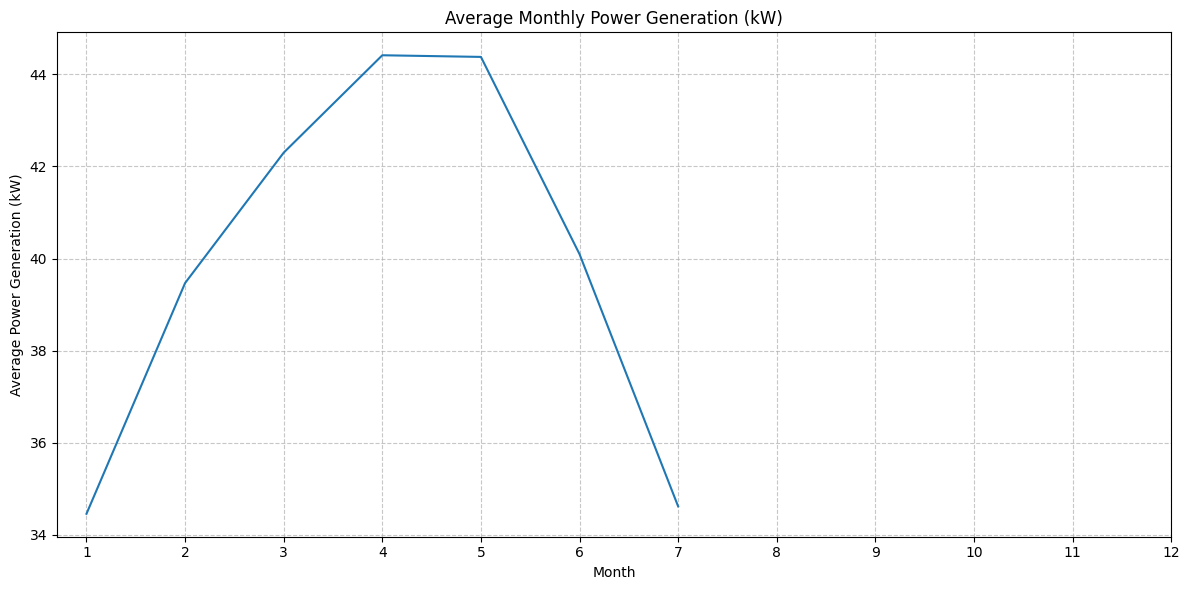

In [ ]:
# Calculate average monthly power generation
avg_monthly_generation = df.groupby('month')['power_generation_kw'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='power_generation_kw', data=avg_monthly_generation)
plt.title('Average Monthly Power Generation (kW)')
plt.xlabel('Month')
plt.ylabel('Average Power Generation (kW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Key Visual Observations
* Data Coverage Issue (Incomplete Year):The dataset only covers Months 1 through 7 (January to July).Months 8 through 12 (August to December) are completely missing.
* Peak Production Period (Months 4 & 5):Generation peaks in April and May at approximately 44.4 kW.This peak aligns with longer spring/early-summer daylight hours and high solar position before mid-summer cloud cover or monsoons arrive.
* Sharp Summer Drop (Months 5 to 7):Output drops drastically from ~44.4 kW in May down to ~34.6 kW in July—a ~22% reduction in power generation in just two months.
* This sharp decline is typical of the onset of the monsoon / heavy rainy season (increased cloud_cover_percent) coupled with panel thermal derating (high ambient/panel temperatures reducing PV panel efficiency).
* January has the lowest power output in the available range at ~34.5 kW, driven by shorter day lengths and lower solar elevation angles.

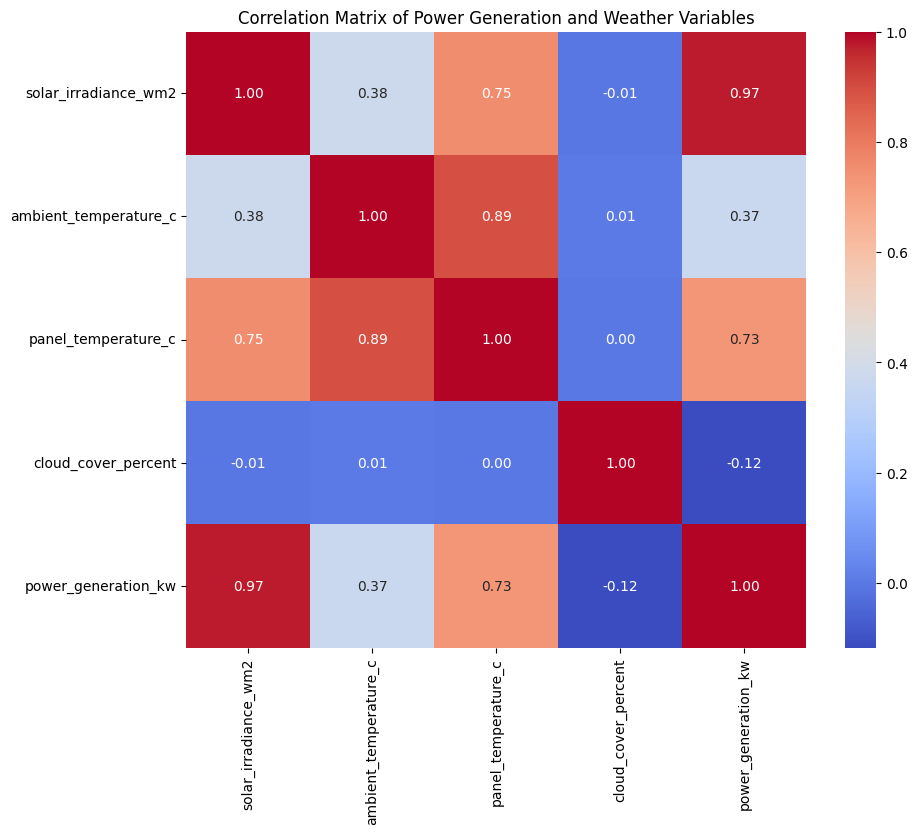

,power_generation_kw
solar_irradiance_wm2,0.974654
ambient_temperature_c,0.365665
panel_temperature_c,0.732168
cloud_cover_percent,-0.117163
power_generation_kw,1.000000


In [ ]:
weather_features = ['solar_irradiance_wm2', 'ambient_temperature_c', 'panel_temperature_c', 'cloud_cover_percent', 'power_generation_kw']
correlation_matrix = df[weather_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Power Generation and Weather Variables')
plt.show()

display(correlation_matrix[['power_generation_kw']])

##From the output, we can observe the following correlations with Power Generation:

* solar irradiance: 0.97 (Very strong positive correlation)
* panel temperature: 0.73 (Strong positive correlation)
* ambient temperature: 0.37 (Moderate positive correlation)
* cloud cover percent: -0.12 (Weak negative correlation)
* This indicates that solar irradiance and panel temperature are the most influential weather factors for power generation, as expected, while cloud cover percent has a minor negative impact.

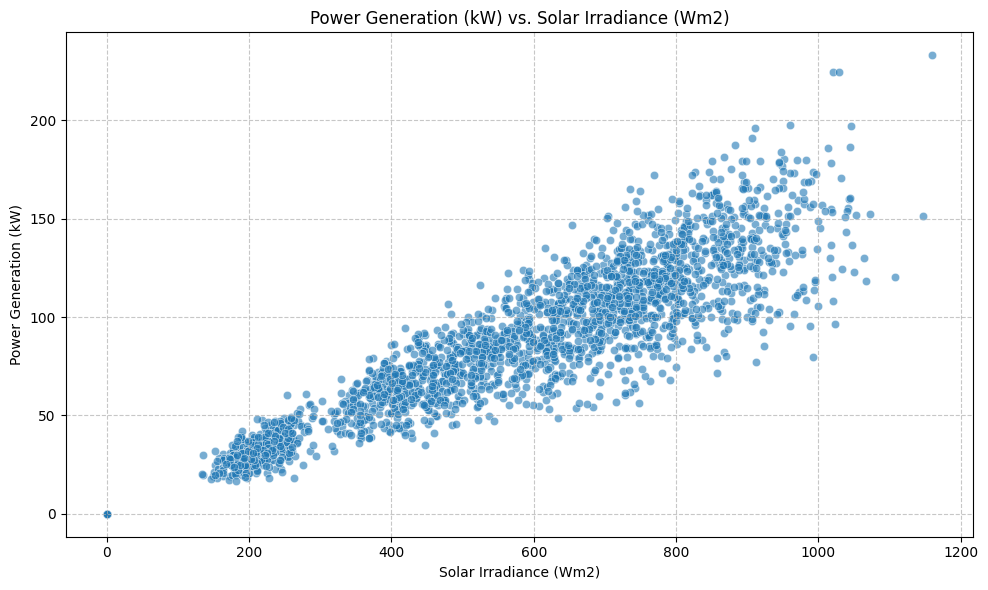

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='solar_irradiance_wm2', y='power_generation_kw', data=df, alpha=0.6)
plt.title('Power Generation (kW) vs. Solar Irradiance (Wm2)')
plt.xlabel('Solar Irradiance (Wm2)')
plt.ylabel('Power Generation (kW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

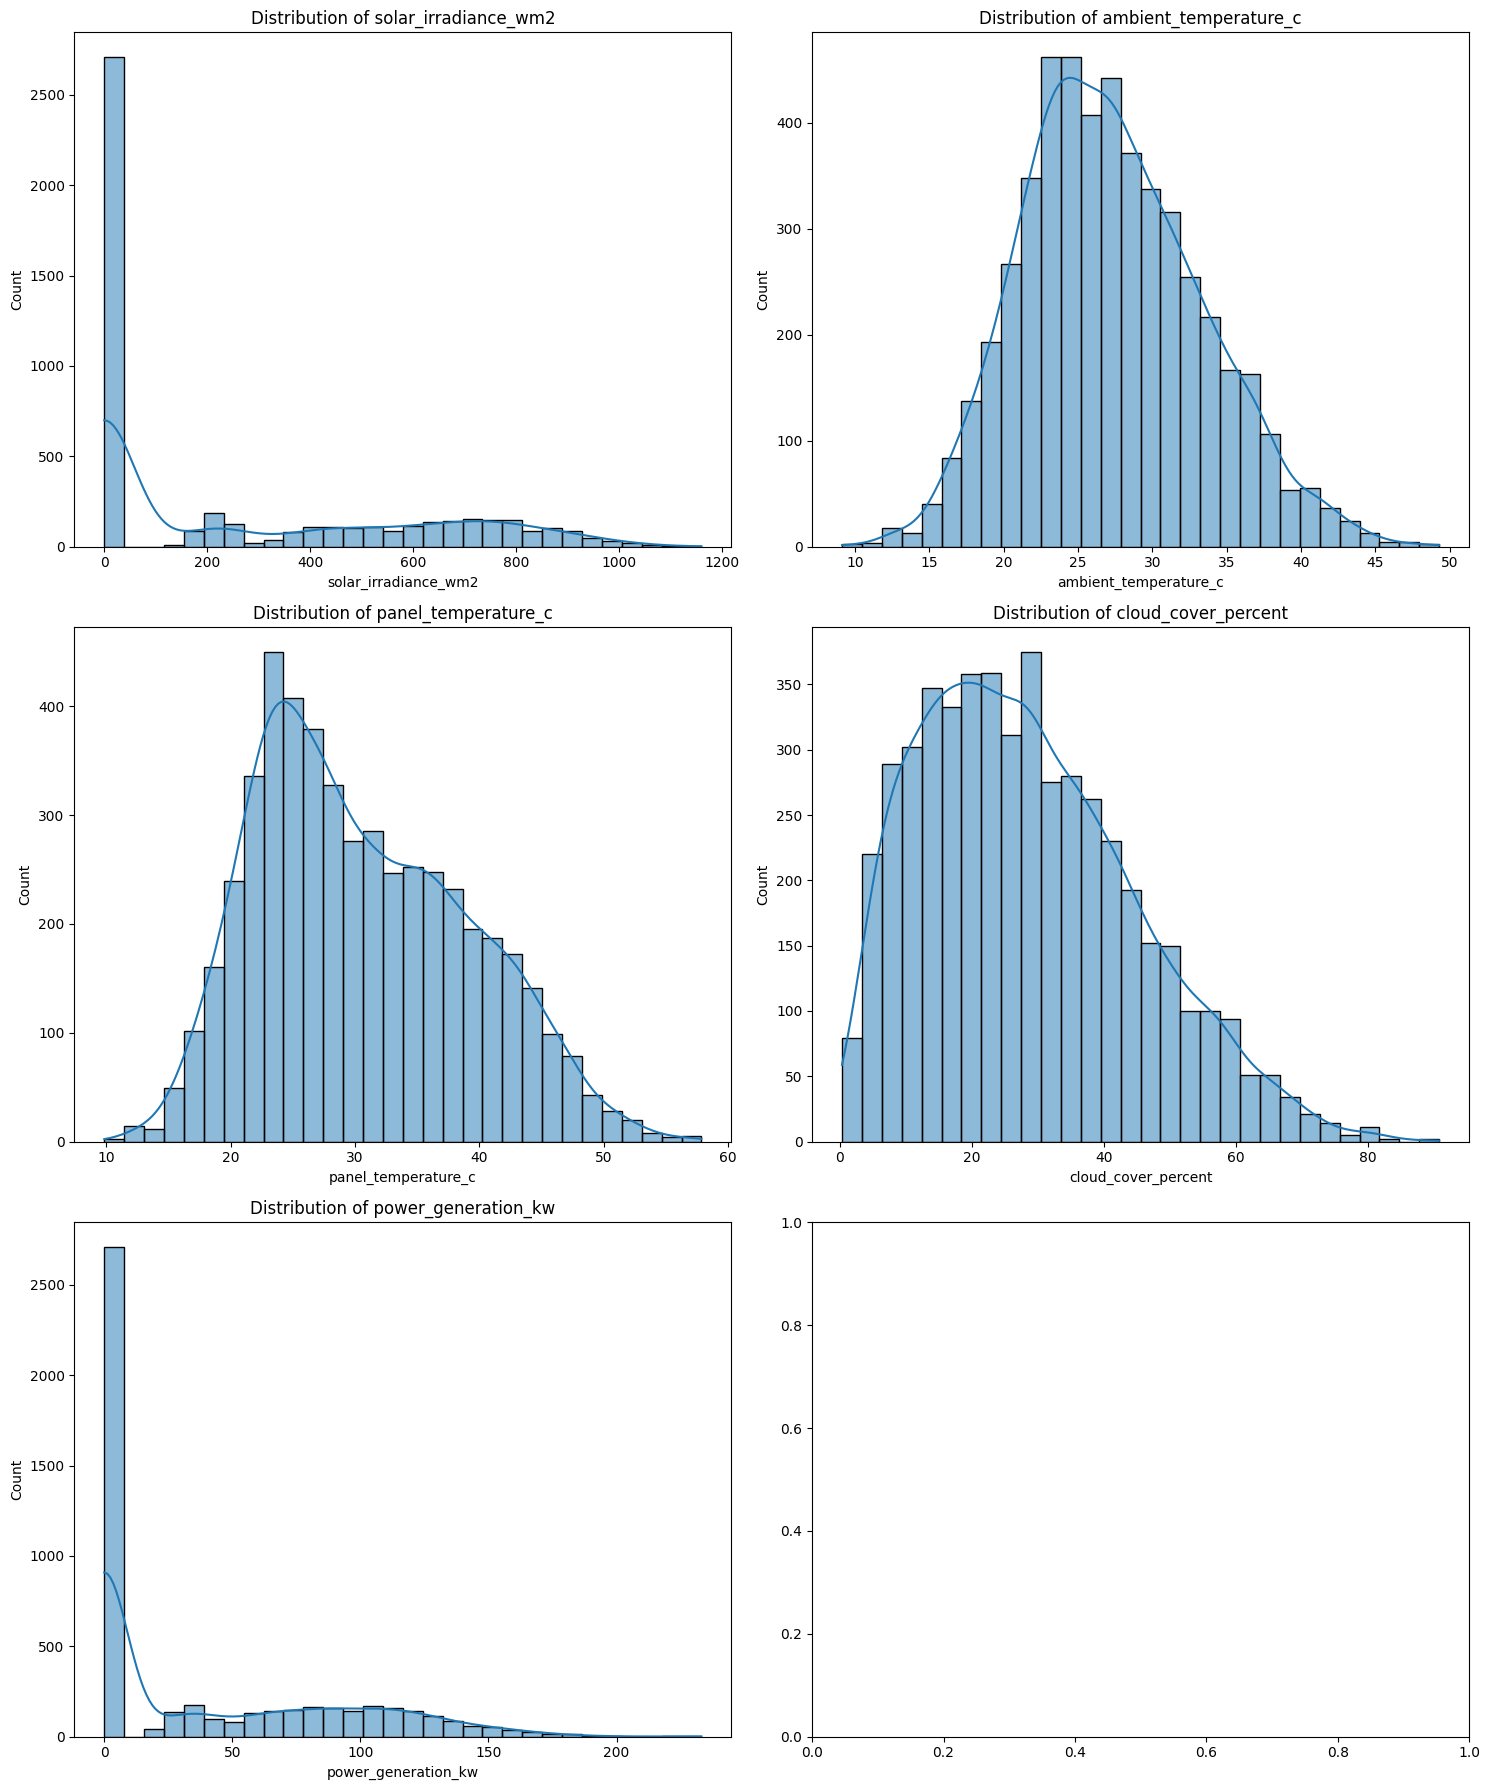

In [ ]:
## Distribution of Numeric Features
numeric_features = ['solar_irradiance_wm2', 'ambient_temperature_c', 'panel_temperature_c', 'cloud_cover_percent', 'power_generation_kw']

# Plotting histograms for each numeric feature
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.ravel()
for i, feature in enumerate(numeric_features):
    sns.histplot(df[feature], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## Feature Engineering createing lag features for forecasting

In [ ]:
# Target Lags (Historical context)
df["power_lag_1h"] = df["power_generation_kw"].shift(1)
df["power_lag_2h"] = df["power_generation_kw"].shift(2)
df["power_lag_24h"] = df["power_generation_kw"].shift(24)  # Same time yesterday

# Rolling Statistics (3-hour window)
df["power_roll_mean_3h"] = df["power_generation_kw"].shift(1).rolling(3).mean()
df["irradiance_roll_mean_3h"] = df["solar_irradiance_wm2"].shift(1).rolling(3).mean()

# Drop initial NaNs created by lag shifting
df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

,timestamp,solar_irradiance_wm2,ambient_temperature_c,panel_temperature_c,cloud_cover_percent,power_generation_kw,hour,day,month,dayofweek,is_weekend,hour_sin,hour_cos,month_sin,month_cos,power_lag_1h,power_lag_2h,power_lag_24h,power_roll_mean_3h,irradiance_roll_mean_3h
0,2025-01-02 00:00:00,0.0,24.27,24.27,59.89,0.0,0,2,1,3,0,0.000000,1.000000,0.5,0.866025,0.0,0.0,0.0,0.0,0.0
1,2025-01-02 01:00:00,0.0,22.45,22.45,45.41,0.0,1,2,1,3,0,0.258819,0.965926,0.5,0.866025,0.0,0.0,0.0,0.0,0.0
2,2025-01-02 02:00:00,0.0,19.08,19.08,10.31,0.0,2,2,1,3,0,0.500000,0.866025,0.5,0.866025,0.0,0.0,0.0,0.0,0.0
3,2025-01-02 03:00:00,0.0,18.24,18.24,24.67,0.0,3,2,1,3,0,0.707107,0.707107,0.5,0.866025,0.0,0.0,0.0,0.0,0.0
4,2025-01-02 04:00:00,0.0,25.19,25.19,38.75,0.0,4,2,1,3,0,0.866025,0.500000,0.5,0.866025,0.0,0.0,0.0,0.0,0.0


In [ ]:
df["temp_delta"] = df["panel_temperature_c"] - df["ambient_temperature_c"]

In [ ]:
# Define feature columns
features = [
    "solar_irradiance_wm2",
    "ambient_temperature_c",
    "panel_temperature_c",
    "cloud_cover_percent",
    "temp_delta",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "power_lag_1h",
    "power_lag_2h",
    "power_lag_24h",
    "power_roll_mean_3h",
    "irradiance_roll_mean_3h",
]
target = "power_generation_kw"

In [ ]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# Filter daytime hours for training to prevent zero-inflation noise
train_daytime = train_df[train_df["solar_irradiance_wm2"] > 5]

X_train = train_daytime[features]
y_train = train_daytime[target]

X_test = test_df[features]
y_test = test_df[target]

## Model Training: XGBoost Regressor

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage to prevent overfitting
    max_depth=5,                  # Maximum depth of a tree
    random_state=42               # For reproducibility
)

xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


## Model Evaluation

In [ ]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 17.37
Root Mean Squared Error (RMSE): 20.23
R-squared (R2): 0.81


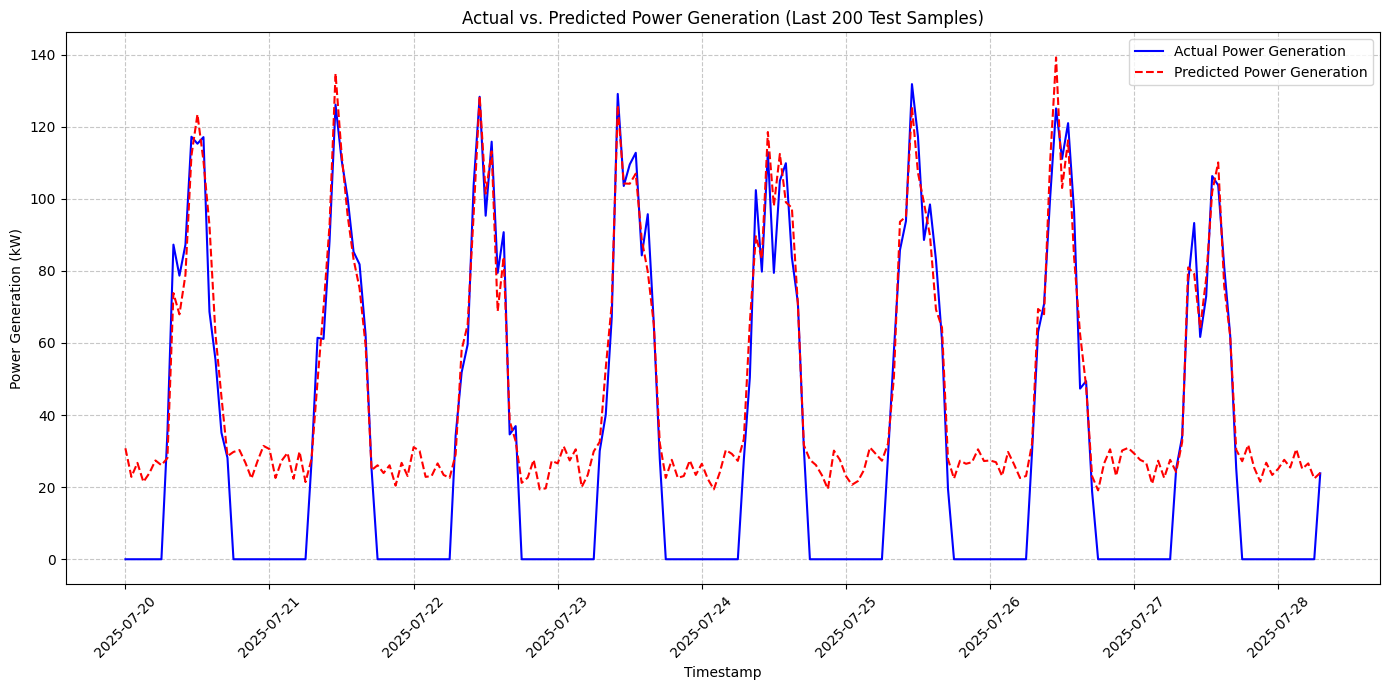

In [ ]:
# Visualize actual vs. predicted values for a subset of the test data
plt.figure(figsize=(14, 7))
plt.plot(test_df['timestamp'].iloc[-200:], y_test.iloc[-200:], label='Actual Power Generation', color='blue')
plt.plot(test_df['timestamp'].iloc[-200:], y_pred[-200:], label='Predicted Power Generation', color='red', linestyle='--')
plt.title('Actual vs. Predicted Power Generation (Last 200 Test Samples)')
plt.xlabel('Timestamp')
plt.ylabel('Power Generation (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Train LightGBM

In [ ]:
import lightgbm as lgb
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# ==========================================
# 5. PREDICTION & NIGHTTIME POST-PROCESSING
# ==========================================
raw_preds = model.predict(X_test)

# Post-processing Rule: Force night predictions to 0 kW
predictions = np.where(test_df["solar_irradiance_wm2"] <= 5, 0.0, raw_preds)
predictions = np.clip(predictions, 0, None)  # No negative power output

# ==========================================
# 6. EVALUATION METRICS
# ==========================================
def calculate_wape(y_true, y_pred):
    """Weighted Absolute Percentage Error"""
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
wape = calculate_wape(y_test.values, predictions)

print("--- Forecast Performance Metrics ---")
print(f"MAE  : {mae:.2f} kW")
print(f"RMSE : {rmse:.2f} kW")
print(f"WAPE : {wape:.2f}%")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2583
[LightGBM] [Info] Number of data points in the train set: 1826, number of used features: 14
[LightGBM] [Info] Start training from score 89.237399
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")


--- Forecast Performance Metrics ---
MAE  : 3.43 kW
RMSE : 6.83 kW
WAPE : 9.38%


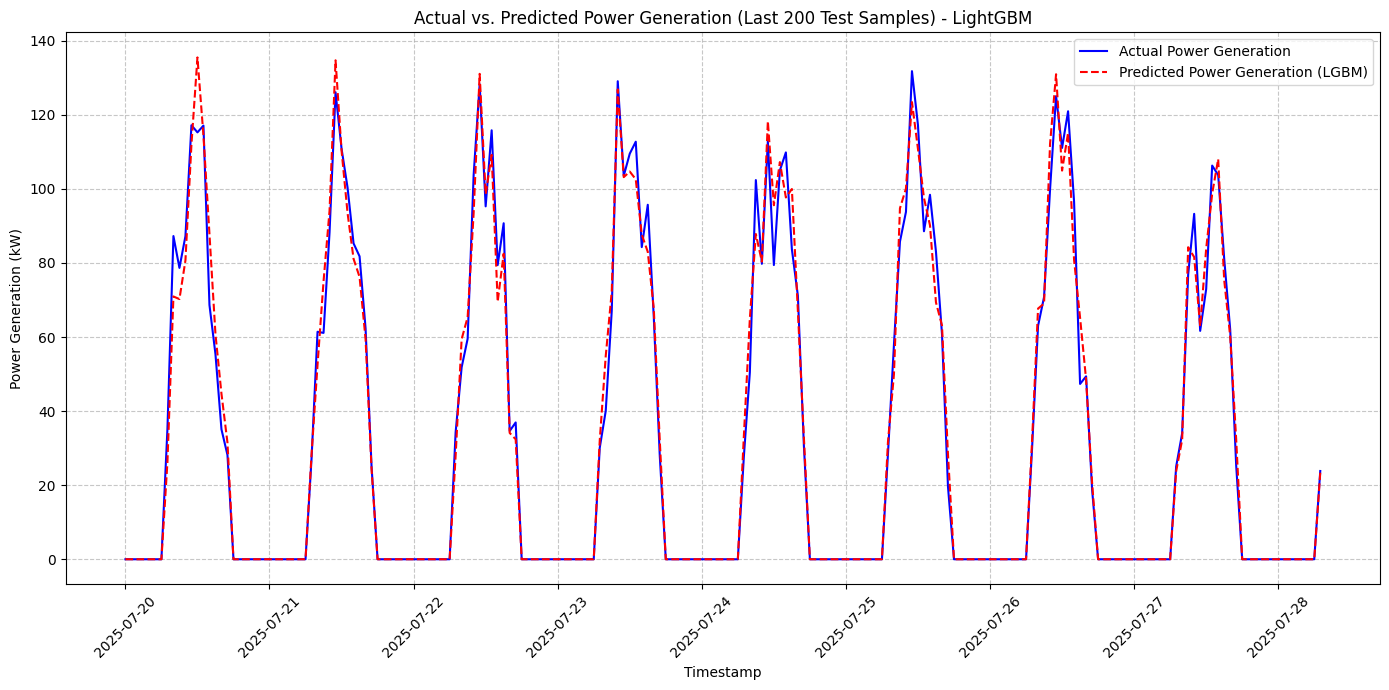

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(test_df['timestamp'].iloc[-200:], y_test.iloc[-200:], label='Actual Power Generation', color='blue')
plt.plot(test_df['timestamp'].iloc[-200:], predictions[-200:], label='Predicted Power Generation (LGBM)', color='red', linestyle='--')
plt.title('Actual vs. Predicted Power Generation (Last 200 Test Samples) - LightGBM')
plt.xlabel('Timestamp')
plt.ylabel('Power Generation (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Importance for LightGBM Model

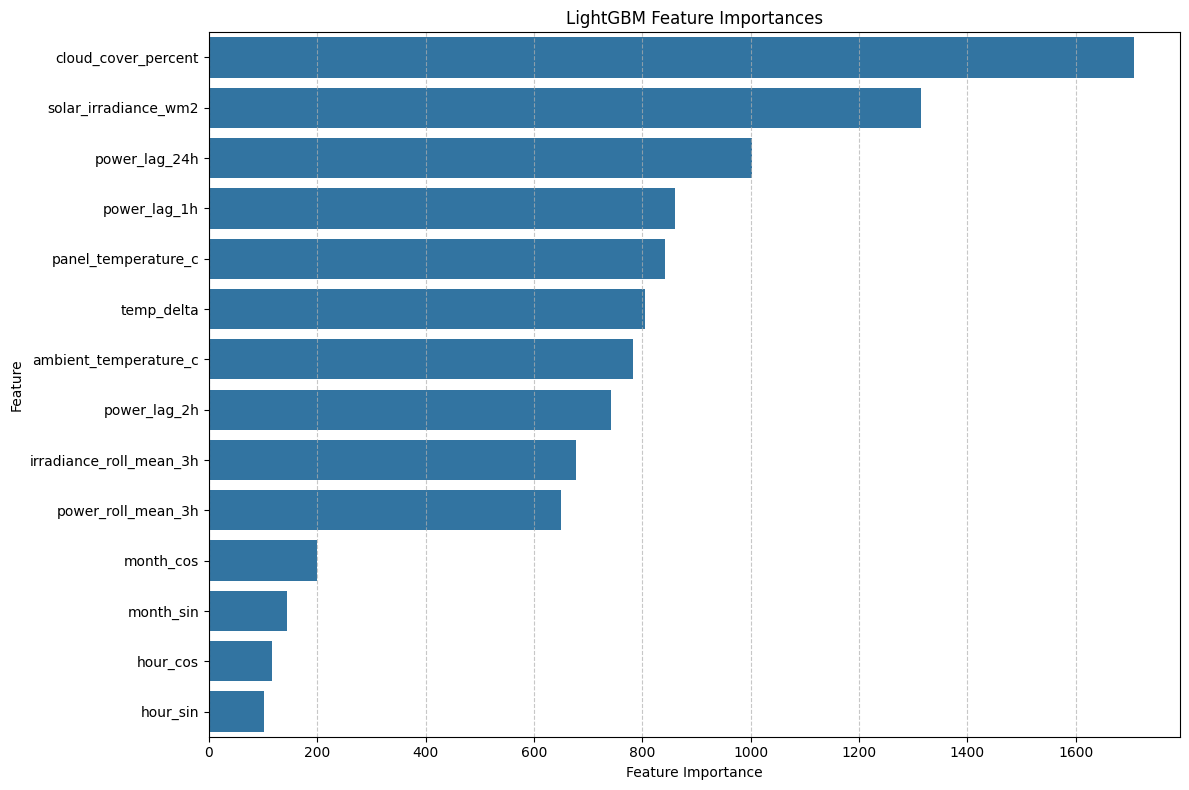

,Feature,Importance
3,cloud_cover_percent,1707
0,solar_irradiance_wm2,1315
11,power_lag_24h,1002
9,power_lag_1h,860
2,panel_temperature_c,841
4,temp_delta,804
1,ambient_temperature_c,782
10,power_lag_2h,742
13,irradiance_roll_mean_3h,677
12,power_roll_mean_3h,650


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained LightGBM model
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('LightGBM Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(importance_df)

## Hyperparameter Tuning with Optuna for LightGBM

In [ ]:
# Install Optuna if not already installed
!pip install optuna

import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 31.0 MB/s eta 0:00:00


In [ ]:
def objective(trial):
    # Define hyperparameters to tune
    param = {
        'objective': 'regression_l1', # MAE objective
        'metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'n_jobs': -1, # Use all available cores
        'verbose': -1 # Suppress verbose output during tuning
    }

    model = lgb.LGBMRegressor(**param)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train)],
        callbacks=[lgb.early_stopping(50, verbose=False)] # Use early stopping
    )

    raw_preds = model.predict(X_test)
    predictions = np.where(test_df["solar_irradiance_wm2"] <= 5, 0.0, raw_preds)
    predictions = np.clip(predictions, 0, None)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    return rmse

In [ ]:
# Create an Optuna study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50) # Run 50 trials for demonstration

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-07-27 09:47:07,621] A new study created in memory with name: no-name-a0bc18f9-cd9b-4540-b470-d9b6c09d0a33
/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")
[I 2026-07-27 09:47:08,128] Trial 0 finished with value: 6.880205287653723 and parameters: {'n_estimators': 514, 'learning_rate': 0.059217265455690234, 'num_leaves': 73, 'max_depth': 9, 'min_child_samples': 92, 'subsample': 0.8128919486854629, 'colsample_bytree': 0.6059907289783917, 'reg_alpha': 4.228951543101352e-08, 'reg_lambda': 4.3387318620383924e-07}. Best is trial 0 with value: 6.880205287653723.
/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:347: UserWarning: Only training set found, disabling early stopping.
  _log_warning("Only training set found, disabling early stopping.")
[I 2026-07-27 09:47:09,986] Trial 1 finished with value: 6.807208715365959 and par

Number of finished trials:  50
Best trial:
  Value: 6.5968
  Params: 
    n_estimators: 285
    learning_rate: 0.025007095852630074
    num_leaves: 45
    max_depth: 3
    min_child_samples: 67
    subsample: 0.9435647151768969
    colsample_bytree: 0.830694320787165
    reg_alpha: 0.0005130774795967069
    reg_lambda: 0.05049492367183974


## Retraining LightGBM with Optimized Hyperparameters

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Get the best parameters from the Optuna study
best_params = study.best_trial.params

# Initialize and train the LightGBM model with optimized parameters
optimized_lgbm_model = lgb.LGBMRegressor(
    objective='regression_l1', # Use MAE objective as specified in Optuna objective
    metric='rmse',
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    num_leaves=best_params['num_leaves'],
    max_depth=best_params['max_depth'],
    min_child_samples=best_params['min_child_samples'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

optimized_lgbm_model.fit(X_train, y_train)

print("LightGBM model retraining with optimized hyperparameters complete.")

LightGBM model retraining with optimized hyperparameters complete.


## Evaluation of Optimized LightGBM Model

In [ ]:
# Make predictions on the test set using the optimized model
optimized_raw_preds = optimized_lgbm_model.predict(X_test)

# Apply post-processing rules
optimized_predictions = np.where(test_df["solar_irradiance_wm2"] <= 5, 0.0, optimized_raw_preds)
optimized_predictions = np.clip(optimized_predictions, 0, None)

# Evaluate the optimized model
optimized_mae = mean_absolute_error(y_test, optimized_predictions)
optimized_rmse = np.sqrt(mean_squared_error(y_test, optimized_predictions))
optimized_wape = calculate_wape(y_test.values, optimized_predictions)

print("--- Optimized LightGBM Forecast Performance Metrics ---")
print(f"MAE  : {optimized_mae:.2f} kW")
print(f"RMSE : {optimized_rmse:.2f} kW")
print(f"WAPE : {optimized_wape:.2f}%")

--- Optimized LightGBM Forecast Performance Metrics ---
MAE  : 3.33 kW
RMSE : 6.60 kW
WAPE : 9.12%


## Visualize Optimized LightGBM Model Performance

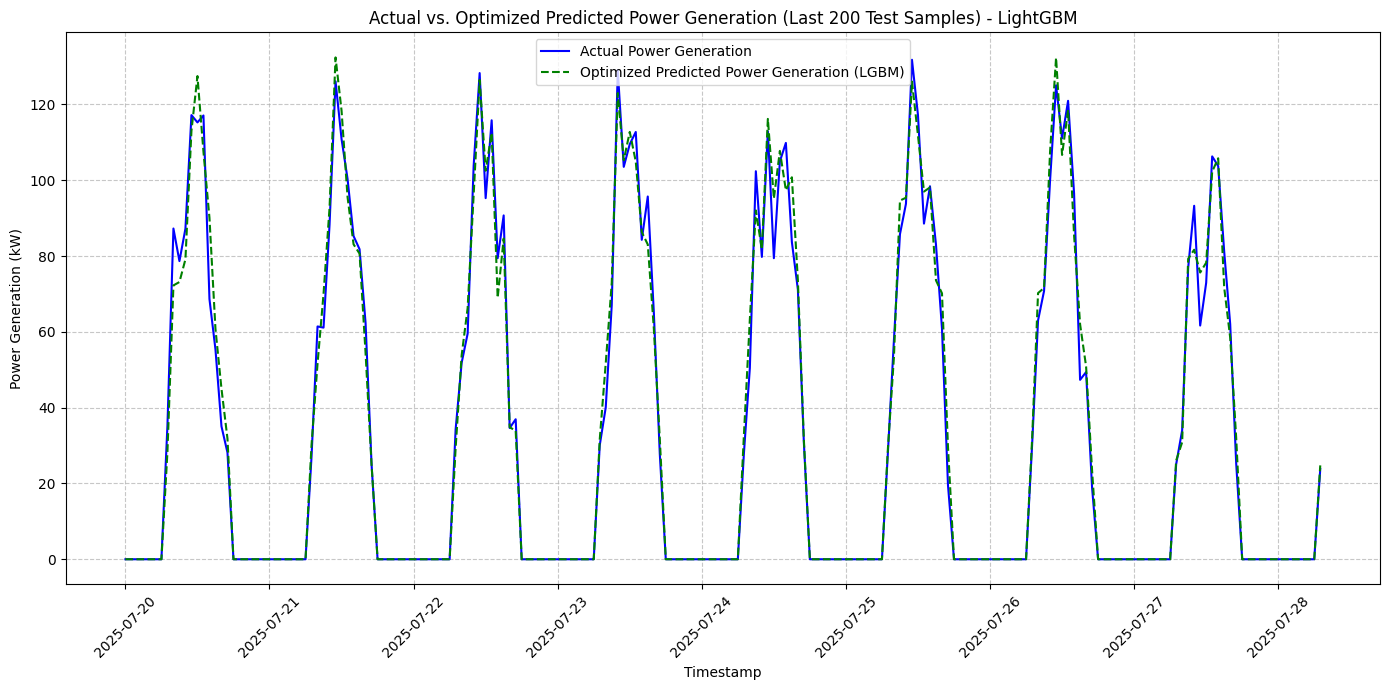

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(test_df['timestamp'].iloc[-200:], y_test.iloc[-200:], label='Actual Power Generation', color='blue')
plt.plot(test_df['timestamp'].iloc[-200:], optimized_predictions[-200:], label='Optimized Predicted Power Generation (LGBM)', color='green', linestyle='--')
plt.title('Actual vs. Optimized Predicted Power Generation (Last 200 Test Samples) - LightGBM')
plt.xlabel('Timestamp')
plt.ylabel('Power Generation (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()